<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [9]</a>'.</span>

# BOOMER Evaluation Tutorial

This notebook demonstrates how to evaluate BOOMER's reasoning performance using ground truth data.

## Overview

Evaluation in BOOMER helps you:
- Measure reasoning accuracy against known facts
- Compare different configurations
- Find optimal probability thresholds
- Identify systematic errors in predictions

We'll cover:
1. Basic evaluation metrics
2. Evaluating reasoning results
3. Type-specific evaluation
4. Grid search with evaluation
5. Analyzing errors

In [1]:
# Import required modules
from boomer.evaluator import evaluate_facts
from boomer.model import KB, SubClassOf, EquivalentTo, DisjointWith
from boomer.reasoners.nx_reasoner import NxReasoner
from boomer.search import solve, grid_search
from boomer.model import SearchConfig, GridSearch
from boomer.datasets import animals, family
import pandas as pd
import matplotlib.pyplot as plt

## 1. Understanding Evaluation Metrics

BOOMER computes standard classification metrics for fact prediction:

In [2]:
# Create simple ground truth and predictions
ground_truth = [
    SubClassOf(sub="Cat", sup="Mammal"),
    SubClassOf(sub="Dog", sup="Mammal"),
    SubClassOf(sub="Mammal", sup="Animal"),
    EquivalentTo(sub="Cat", equivalent="Feline")
]

predictions = [
    SubClassOf(sub="Cat", sup="Mammal"),      # True Positive
    SubClassOf(sub="Dog", sup="Mammal"),      # True Positive
    SubClassOf(sub="Bird", sup="Animal"),     # False Positive
    # Missing: Mammal->Animal (False Negative)
    # Missing: Cat≡Feline (False Negative)
]

# Evaluate
stats = evaluate_facts(ground_truth, predictions)

print(f"True Positives: {stats.tp}")
print(f"False Positives: {stats.fp}")
print(f"False Negatives: {stats.fn}")
print(f"Precision: {stats.precision:.3f}")
print(f"Recall: {stats.recall:.3f}")
print(f"F1 Score: {stats.f1:.3f}")

True Positives: 2
False Positives: 1
False Negatives: 2
Precision: 0.667
Recall: 0.500
F1 Score: 0.571


## 2. Evaluating Reasoning Results

Let's evaluate a complete reasoning workflow using a real dataset:

In [3]:
# Load the animals dataset
kb = animals.kb
print(f"Dataset: {kb.name}")
print(f"Facts: {len(kb.facts)}")
print(f"Probabilistic facts: {len(kb.pfacts)}")

# Split into training and test sets
train_facts = kb.facts[:30]  # Use first 30 facts for training
test_facts = kb.facts[30:]   # Rest for testing

# Also keep some probabilistic facts for hypothesis generation
train_pfacts = kb.pfacts[:20]

print(f"\nTraining facts: {len(train_facts)}")
print(f"Test facts: {len(test_facts)}")

Dataset: Animals
Facts: 8
Probabilistic facts: 9

Training facts: 8
Test facts: 0


In [4]:
# Create training KB and run reasoning
train_kb = KB(
    name="Animals Training",
    facts=train_facts,
    pfacts=train_pfacts
)

# Configure and run search
config = SearchConfig(
    max_iterations=10000,
    max_candidate_solutions=100
)

solution = solve(train_kb, config)
print(f"Solution confidence: {solution.confidence:.3f}")
print(f"Solved probabilistic facts: {len(solution.solved_pfacts)}")

Solving KB: Animals Training with 9 pfacts; threshold=200


Solution confidence: 0.900
Solved probabilistic facts: 9


In [5]:
# Extract predictions with different probability thresholds
thresholds = [0.5, 0.7, 0.9]
results = []

for threshold in thresholds:
    # Filter predictions by posterior probability
    predictions = [
        spf.pfact.fact 
        for spf in solution.solved_pfacts 
        if spf.truth_value and spf.posterior_prob >= threshold
    ]
    
    # Evaluate against test set
    stats = evaluate_facts(test_facts, predictions)
    
    results.append({
        'threshold': threshold,
        'predictions': len(predictions),
        'precision': stats.precision,
        'recall': stats.recall,
        'f1': stats.f1,
        'tp': stats.tp,
        'fp': stats.fp,
        'fn': stats.fn
    })

# Display results
df = pd.DataFrame(results)
print(df.to_string(index=False))

 threshold  predictions  precision  recall  f1  tp  fp  fn
       0.5            3        0.0     0.0 0.0   0   3   0
       0.7            3        0.0     0.0 0.0   0   3   0
       0.9            0        0.0     0.0 0.0   0   0   0


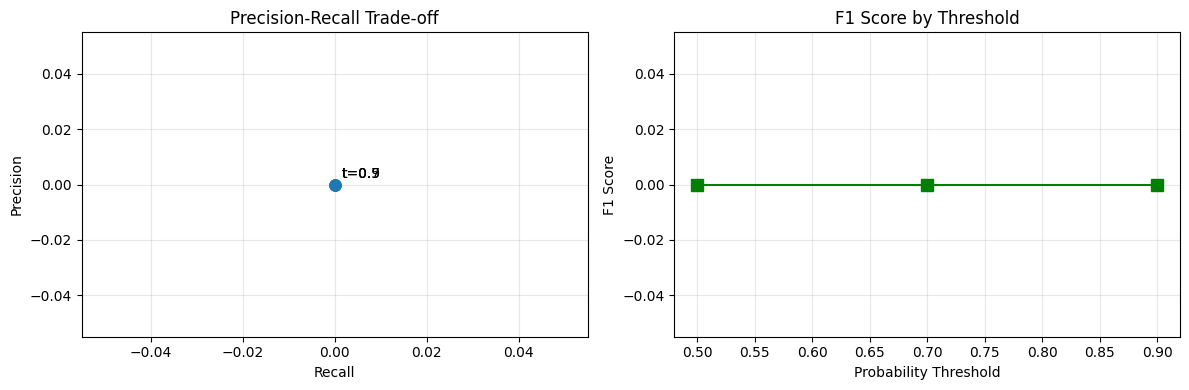

In [6]:
# Visualize precision-recall trade-off
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Precision vs Recall
ax1.plot(df['recall'], df['precision'], 'o-', markersize=8)
for idx, row in df.iterrows():
    ax1.annotate(f"t={row['threshold']}", 
                (row['recall'], row['precision']),
                textcoords="offset points", xytext=(5,5))
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Trade-off')
ax1.grid(True, alpha=0.3)

# F1 Score vs Threshold
ax2.plot(df['threshold'], df['f1'], 's-', markersize=8, color='green')
ax2.set_xlabel('Probability Threshold')
ax2.set_ylabel('F1 Score')
ax2.set_title('F1 Score by Threshold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Type-Specific Evaluation

Evaluate performance on specific types of facts to understand reasoning capabilities:

In [7]:
# Create a KB with mixed fact types
mixed_kb = KB(
    name="Mixed Facts",
    facts=[
        SubClassOf(sub="A", sup="B"),
        SubClassOf(sub="B", sup="C"),
        EquivalentTo(sub="X", equivalent="Y")
    ],
    pfacts=[]
)

# Generate some predictions
predicted_facts = [
    SubClassOf(sub="A", sup="B"),  # Correct
    SubClassOf(sub="A", sup="C"),  # Correct (inferred)
    SubClassOf(sub="B", sup="D"),  # Wrong
    EquivalentTo(sub="X", equivalent="Y"),  # Correct
    EquivalentTo(sub="Y", equivalent="Z")  # Wrong
]

# Evaluate all facts
all_stats = evaluate_facts(mixed_kb.facts, predicted_facts)
print("All fact types:")
print(f"  F1 Score: {all_stats.f1:.3f}")
print(f"  Precision: {all_stats.precision:.3f}")
print(f"  Recall: {all_stats.recall:.3f}")

# Evaluate only SubClassOf facts
subclass_stats = evaluate_facts(mixed_kb.facts, predicted_facts, 
                                types=["SubClassOf"])
print("\nSubClassOf facts only:")
print(f"  F1 Score: {subclass_stats.f1:.3f}")
print(f"  Precision: {subclass_stats.precision:.3f}")
print(f"  Recall: {subclass_stats.recall:.3f}")

# Evaluate only EquivalentTo facts
equiv_stats = evaluate_facts(mixed_kb.facts, predicted_facts, 
                             types=["EquivalentTo"])
print("\nEquivalentTo facts only:")
print(f"  F1 Score: {equiv_stats.f1:.3f}")
print(f"  Precision: {equiv_stats.precision:.3f}")
print(f"  Recall: {equiv_stats.recall:.3f}")

All fact types:
  F1 Score: 0.500
  Precision: 0.400
  Recall: 0.667

SubClassOf facts only:
  F1 Score: 0.400
  Precision: 0.333
  Recall: 0.500

EquivalentTo facts only:
  F1 Score: 0.667
  Precision: 0.500
  Recall: 1.000


## 4. Grid Search with Automatic Evaluation

Find the best configuration by testing multiple parameter combinations:

In [8]:
# Prepare train/test split
family_kb = family.kb
train_kb = KB(
    name="Family Training",
    facts=family_kb.facts[:15],
    pfacts=family_kb.pfacts[:10]
)
test_kb = KB(
    name="Family Test",
    facts=family_kb.facts[15:]
)

print(f"Training: {len(train_kb.facts)} facts, {len(train_kb.pfacts)} pfacts")
print(f"Testing: {len(test_kb.facts)} facts")

Training: 15 facts, 10 pfacts
Testing: 3 facts


<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [9]:
# Define grid search configuration
grid_config = GridSearch(
    base_config=SearchConfig(
        max_iterations=5000,
        max_candidate_solutions=50
    ),
    configuration_matrix={
        "max_hypotheses": [50, 100, 200],
        "alpha": [0.05, 0.1, 0.2],
        "beta": [0.01, 0.05]
    },
    pr_filters=[0.5, 0.7, 0.9]  # Test multiple thresholds
)

# Run grid search with evaluation
print("Running grid search (this may take a moment)...")
grid_result = grid_search(train_kb, grid_config, test_kb)

print(f"\nCompleted {len(grid_result.results)} configurations")

ValidationError: 1 validation error for GridSearch
configurations
  Field required [type=missing, input_value={'base_config': SearchCon...lters': [0.5, 0.7, 0.9]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.11/v/missing

In [ ]:
# Analyze grid search results
results_data = []
for r in grid_result.results:
    if r.evaluation:
        results_data.append({
            'alpha': r.config.alpha,
            'beta': r.config.beta,
            'max_hypotheses': r.config.max_hypotheses,
            'pr_filter': r.pr_filter,
            'f1': r.evaluation.f1,
            'precision': r.evaluation.precision,
            'recall': r.evaluation.recall
        })

results_df = pd.DataFrame(results_data)

# Find best configuration by F1 score
best_idx = results_df['f1'].idxmax()
best_config = results_df.iloc[best_idx]

print("Best configuration:")
print(f"  Alpha: {best_config['alpha']}")
print(f"  Beta: {best_config['beta']}")
print(f"  Max hypotheses: {best_config['max_hypotheses']}")
print(f"  Probability threshold: {best_config['pr_filter']}")
print(f"  F1 Score: {best_config['f1']:.3f}")
print(f"  Precision: {best_config['precision']:.3f}")
print(f"  Recall: {best_config['recall']:.3f}")

In [ ]:
# Visualize parameter impact on F1 score
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Group by alpha
alpha_group = results_df.groupby('alpha')['f1'].mean().reset_index()
axes[0, 0].bar(alpha_group['alpha'].astype(str), alpha_group['f1'])
axes[0, 0].set_xlabel('Alpha')
axes[0, 0].set_ylabel('Mean F1 Score')
axes[0, 0].set_title('Impact of Alpha on F1')

# Group by beta
beta_group = results_df.groupby('beta')['f1'].mean().reset_index()
axes[0, 1].bar(beta_group['beta'].astype(str), beta_group['f1'])
axes[0, 1].set_xlabel('Beta')
axes[0, 1].set_ylabel('Mean F1 Score')
axes[0, 1].set_title('Impact of Beta on F1')

# Group by max_hypotheses
hyp_group = results_df.groupby('max_hypotheses')['f1'].mean().reset_index()
axes[1, 0].bar(hyp_group['max_hypotheses'].astype(str), hyp_group['f1'])
axes[1, 0].set_xlabel('Max Hypotheses')
axes[1, 0].set_ylabel('Mean F1 Score')
axes[1, 0].set_title('Impact of Max Hypotheses on F1')

# Group by pr_filter
pr_group = results_df.groupby('pr_filter')['f1'].mean().reset_index()
axes[1, 1].bar(pr_group['pr_filter'].astype(str), pr_group['f1'])
axes[1, 1].set_xlabel('Probability Threshold')
axes[1, 1].set_ylabel('Mean F1 Score')
axes[1, 1].set_title('Impact of Threshold on F1')

plt.tight_layout()
plt.show()

## 5. Error Analysis

Examine false positives and false negatives to understand reasoning errors:

In [ ]:
# Run evaluation with detailed fact lists
threshold = 0.7
predictions = [
    spf.pfact.fact 
    for spf in solution.solved_pfacts 
    if spf.truth_value and spf.posterior_prob >= threshold
]

stats = evaluate_facts(test_facts, predictions)

print(f"Evaluation at threshold {threshold}:")
print(f"  F1 Score: {stats.f1:.3f}")
print(f"  True Positives: {stats.tp}")
print(f"  False Positives: {stats.fp}")
print(f"  False Negatives: {stats.fn}")

In [ ]:
# Examine false positives
print("False Positives (incorrectly predicted):")
if stats.fp_list:
    for i, fact in enumerate(stats.fp_list[:5], 1):  # Show first 5
        print(f"  {i}. {fact}")
else:
    print("  None")

print(f"\nTotal false positives: {len(stats.fp_list) if stats.fp_list else 0}")

In [ ]:
# Examine false negatives
print("False Negatives (missed facts):")
if stats.fn_list:
    for i, fact in enumerate(stats.fn_list[:5], 1):  # Show first 5
        print(f"  {i}. {fact}")
else:
    print("  None")

print(f"\nTotal false negatives: {len(stats.fn_list) if stats.fn_list else 0}")

In [ ]:
# Analyze error patterns
if stats.fp_list:
    fp_types = {}
    for fact in stats.fp_list:
        fact_type = type(fact).__name__
        fp_types[fact_type] = fp_types.get(fact_type, 0) + 1
    
    print("False positives by type:")
    for fact_type, count in sorted(fp_types.items()):
        print(f"  {fact_type}: {count}")

if stats.fn_list:
    fn_types = {}
    for fact in stats.fn_list:
        fact_type = type(fact).__name__
        fn_types[fact_type] = fn_types.get(fact_type, 0) + 1
    
    print("\nFalse negatives by type:")
    for fact_type, count in sorted(fn_types.items()):
        print(f"  {fact_type}: {count}")

## 6. Creating Custom Evaluation Datasets

Build evaluation datasets with known ground truth:

In [ ]:
# Create a custom evaluation dataset
def create_hierarchy_test():
    """Create a test dataset with a clear hierarchy."""
    
    # Define ground truth hierarchy
    ground_truth = [
        # Direct assertions
        SubClassOf(sub="Siamese", sup="Cat"),
        SubClassOf(sub="Persian", sup="Cat"),
        SubClassOf(sub="Cat", sup="Feline"),
        SubClassOf(sub="Feline", sup="Mammal"),
        SubClassOf(sub="Mammal", sup="Animal"),
        
        # Transitive relations that should be inferred
        SubClassOf(sub="Siamese", sup="Feline"),
        SubClassOf(sub="Siamese", sup="Mammal"),
        SubClassOf(sub="Siamese", sup="Animal"),
        SubClassOf(sub="Cat", sup="Animal"),
        
        # Equivalences
        EquivalentTo(sub="Feline", equivalent="FelidaeFamily")
    ]
    
    # Training set (partial information)
    training_facts = [
        SubClassOf(sub="Siamese", sup="Cat"),
        SubClassOf(sub="Persian", sup="Cat"),
        SubClassOf(sub="Cat", sup="Feline"),
        SubClassOf(sub="Feline", sup="Mammal"),
        SubClassOf(sub="Mammal", sup="Animal"),
        EquivalentTo(sub="Feline", equivalent="FelidaeFamily")
    ]
    
    return ground_truth, training_facts

# Create the test dataset
ground_truth, training_facts = create_hierarchy_test()

print(f"Ground truth facts: {len(ground_truth)}")
print(f"Training facts: {len(training_facts)}")
print(f"Facts to be inferred: {len(ground_truth) - len(training_facts)}")

In [ ]:
# Test reasoning on custom dataset
custom_kb = KB(
    name="Custom Hierarchy",
    facts=training_facts,
    pfacts=[]  # No probabilistic facts for this test
)

# Use reasoner to infer facts
reasoner = NxReasoner()
reasoning_solution = reasoner.reason(custom_kb)

# Extract all inferred facts
inferred_facts = [h.fact for h in reasoning_solution.entailed_hypotheses 
                  if h.truth_value]

print(f"Inferred {len(inferred_facts)} facts")

# Evaluate
eval_stats = evaluate_facts(ground_truth, inferred_facts)
print(f"\nEvaluation results:")
print(f"  Precision: {eval_stats.precision:.3f}")
print(f"  Recall: {eval_stats.recall:.3f}")
print(f"  F1 Score: {eval_stats.f1:.3f}")

if eval_stats.recall < 1.0 and eval_stats.fn_list:
    print(f"\nMissed facts:")
    for fact in eval_stats.fn_list:
        print(f"  - {fact}")

## Summary

This tutorial covered:

1. **Basic Metrics**: Understanding precision, recall, and F1 scores
2. **Threshold Tuning**: Finding optimal probability thresholds
3. **Type-Specific Evaluation**: Measuring performance on different fact types
4. **Grid Search**: Finding best configurations automatically
5. **Error Analysis**: Understanding false positives and negatives
6. **Custom Datasets**: Creating targeted evaluation scenarios

### Key Takeaways

- **Precision vs Recall**: Higher thresholds increase precision but decrease recall
- **F1 Score**: Balances precision and recall for overall performance
- **Grid Search**: Automates finding optimal parameters
- **Error Analysis**: Helps identify systematic reasoning issues
- **Type-Specific**: Different fact types may require different strategies

### Next Steps

- Try evaluation with your own datasets
- Experiment with different reasoning configurations
- Use grid search to optimize for specific metrics
- Analyze errors to improve hypothesis generation